# Мультифрактальный анализ

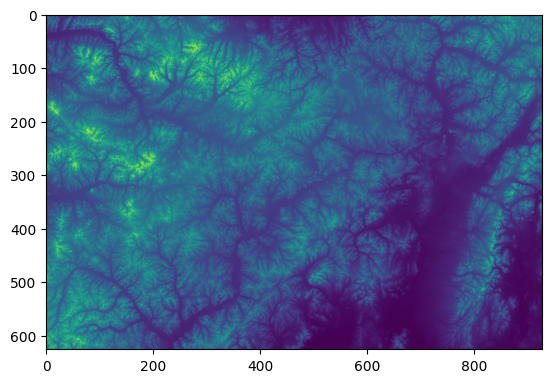

In [1]:
import torch
from pathlib import Path
import rasterio as rs
import matplotlib.pyplot as plt

raster_path = Path(r"D:\ml_datasets\Chukotka\DEM\dem_120m.tif")
ds = rs.open(raster_path)

plt.imshow(ds.read(1)[::10, ::10])

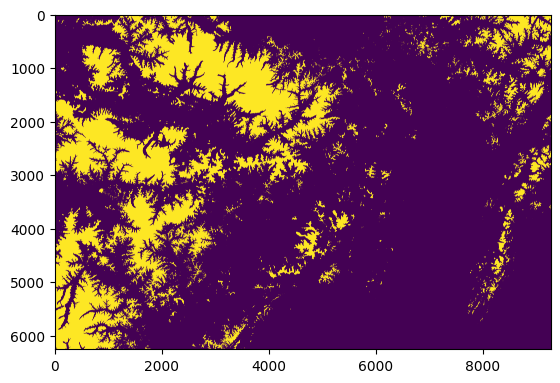

In [2]:
import numpy as np

tensor = torch.tensor(ds.read(1) > np.quantile(ds.read(1), 0.8))
plt.imshow(tensor)

In [3]:
from torch import nn
from utils.box_counting import get_fractal_dimention

from torch.functional import F

patch_size = 64

n = tensor.shape[0] // patch_size 
m = tensor.shape[1] // patch_size 

dx = tensor.shape[0] % patch_size // 2
dy = tensor.shape[1] % patch_size // 2

cropped = tensor[
    dx: dx+n*patch_size, dy:dy+m*patch_size
]

patches = cropped.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)
patches.shape

# get_fractal_dimention(patches[0, 0, :, :])

result = F.max_pool2d(patches[10, 10, :, :].float().unsqueeze(0).unsqueeze(0), kernel_size = 4)[0, 0, :,:]
result


tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1

# Multifractal analysis

In [8]:
from sklearn.linear_model import LinearRegression
from utils.box_counting import get_fractal_dimention
import itertools 

def make_multifractal_analysis(raster: torch.Tensor):
    patch_size = 64

    n = tensor.shape[0] // patch_size 
    m = tensor.shape[1] // patch_size 

    dx = tensor.shape[0] % patch_size // 2
    dy = tensor.shape[1] % patch_size // 2

    cropped = tensor[
        dx: dx+n*patch_size, dy:dy+m*patch_size
    ]

    patches = cropped.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)
    
    multifractal_raster = np.zeros((n, m))
    for x_patch, y_patch in itertools.product(range(n),range(m)):
        multifractal_raster[x_patch, y_patch] = get_fractal_dimention(patches[x_patch, y_patch, :, :])  
    return multifractal_raster 

result = make_multifractal_analysis(tensor)

In [11]:
from scipy import ndimage

result = make_multifractal_analysis(tensor)

# Исходный размер тензора
original_size = (tensor.shape[0], tensor.shape[1])

# Апскейлинг результата до исходного размера
upscaled_result = ndimage.zoom(result, 
                               (original_size[0]/result.shape[0], 
                                original_size[1]/result.shape[1]), 
                               order=3)  # order=3 для кубической интерполяции

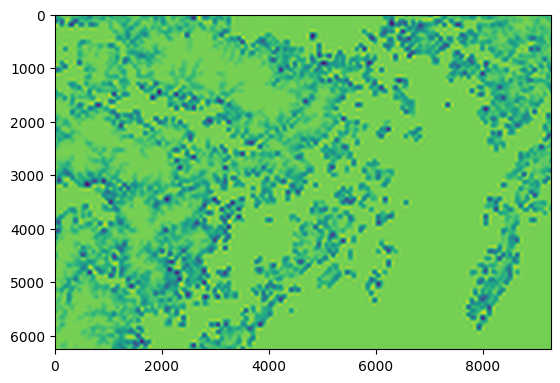

In [12]:
plt.imshow(upscaled_result)

In [19]:
import torch.nn.functional as F

def make_multifractal_analysis(raster: torch.Tensor, return_to_original=True):
    patch_size = 64
    
    # Сохраняем исходный размер
    original_size = (raster.shape[0], raster.shape[1])

    n = raster.shape[0] // patch_size 
    m = raster.shape[1] // patch_size 

    dx = raster.shape[0] % patch_size // 2
    dy = raster.shape[1] % patch_size // 2

    cropped = raster[
        dx: dx+n*patch_size, dy:dy+m*patch_size
    ]

    patches = cropped.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)
    
    multifractal_raster = np.zeros((n, m))
    for x_patch, y_patch in itertools.product(range(n), range(m)):
        multifractal_raster[x_patch, y_patch] = get_fractal_dimention(patches[x_patch, y_patch, :, :])  
    
    if return_to_original:
        # Конвертируем в torch tensor и добавляем размерности для интерполяции
        result_tensor = torch.from_numpy(multifractal_raster).float()
        
        # Добавляем batch и channel dimensions: (1, 1, n, m)
        result_tensor = result_tensor.unsqueeze(0).unsqueeze(0)
        
        # Интерполяция до исходного размера
        upscaled = F.interpolate(
            result_tensor, 
            size=original_size, 
            mode='bilinear', 
            align_corners=False
        )
        
        # Убираем добавленные размерности
        upscaled = upscaled.squeeze(0).squeeze(0)
        
        return upscaled.numpy()
    
    return multifractal_raster

# Использование
result_upscaled = make_multifractal_analysis(tensor, return_to_original=True)
print(f"Исходный размер: {tensor.shape}")
print(f"Размер результата после апскейлинга: {result_upscaled.shape}")

Исходный размер: torch.Size([6253, 9277])
Размер результата после апскейлинга: (6253, 9277)


In [22]:
import torch
import numpy as np
import itertools
from utils.box_counting import get_fractal_dimention

def make_multifractal_analysis(raster: torch.Tensor, fill_edge=np.nan):
    """
    Вычисляет фрактальную размерность для каждого неперекрывающегося патча
    и возвращает карту того же размера, что и исходный растр.
    
    Параметры:
        raster: входной тензор (H, W)
        fill_edge: значение для пикселей на краях, не попавших в полные патчи
                  (по умолчанию NaN)
    
    Возвращает:
        full_map: numpy array размера (H, W) с значениями фрактальной размерности
    """
    patch_size = 64
    h, w = raster.shape[0], raster.shape[1]
    
    # Количество полных патчей по вертикали и горизонтали
    n = h // patch_size
    m = w // patch_size
    
    # Смещение для центрирования области патчей
    dx = (h % patch_size) // 2
    dy = (w % patch_size) // 2
    
    # Вырезаем центральную часть, которая кратна patch_size
    cropped = raster[dx:dx + n * patch_size, dy:dy + m * patch_size]
    
    # Разбиваем на патчи (патчи имеют размер (n, m, patch_size, patch_size))
    patches = cropped.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)
    
    # Вычисляем фрактальную размерность для каждого патча
    fractal_patch_map = np.zeros((n, m))
    for i, j in itertools.product(range(n), range(m)):
        fractal_patch_map[i, j] = get_fractal_dimention(patches[i, j, :, :])
    
    # Создаём карту исходного размера, заполненную fill_edge
    full_map = np.full((h, w), fill_edge, dtype=np.float32)
    
    # Заполняем центральную область, размножая значения патчей на соответствующие блоки
    for i in range(n):
        for j in range(m):
            y_start = dx + i * patch_size
            x_start = dy + j * patch_size
            full_map[y_start:y_start + patch_size, x_start:x_start + patch_size] = fractal_patch_map[i, j]
    
    return full_map

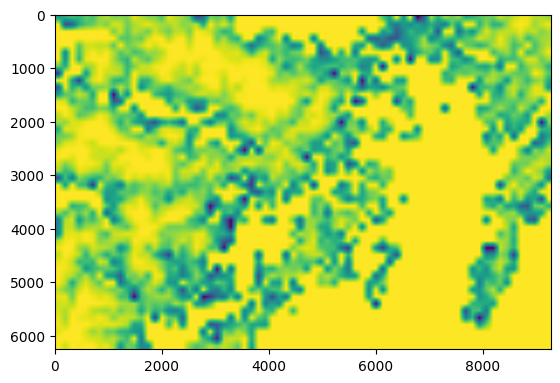

In [ ]:
plt.imshow(make_multifractal_analysis())

In [150]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

model.intercept_

array([1.0020108], dtype=float32)

In [11]:
from pathlib import Path

l1_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Chukotka_ASTER_L1_sorted")
l2_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Chukotka_ASTER_L2xt_sorted")

l1_set = set()
l2_set = set()

for f in l1_dir.iterdir():
    label = f.stem
    l1_set.add(label)


for f in l2_dir.iterdir():
    label = f.stem
    l2_set.add(label)

In [15]:
import shutil

preview_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Chukotka_ASTER_L2_previews")
dst_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Chukotka_ASTER_L2_previews_v3")
dst_dir.mkdir(exist_ok=True)

for f in preview_dir.iterdir():
    print(f.suffix)
    shutil.copy(f, dst_dir / f"{f.stem}.tif")

In [23]:
fine_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Aster_l2_fine")
v3 = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\Chukotka_ASTER_L2_previews_v2")

v3_paths = {}
fine_list = []
for f in v3.iterdir():
    label = f.stem
    v3_paths[label] = f

for f in fine_dir.iterdir():
    id = f.stem
    fine_list.append(id)

In [24]:
selected_fine_dir = Path(r"D:\ml_datasets\Chukotka\Aster_raw\raw\aster_l2_fine_v2")

for fine in fine_list:
    shutil.copy(v3_paths[fine], selected_fine_dir / f"{fine}.tif")